In [48]:
import json
import os
import sys
import cv2
import matplotlib.pyplot as plt

from pathlib import Path

In [3]:
ROOT_DIR = Path.cwd().parent.parent
sys.path.insert(0, str(ROOT_DIR / "src"))

print(ROOT_DIR)

c:\Users\Samuel Oliveira\Desktop\CS\master-degree-project


In [4]:
# 1. Define paths based on your tree structure
json_path = ROOT_DIR / 'data/TAO_Amodal_Dataset/ASPIRe_labels/train.json'
frames_dir = ROOT_DIR / 'data/TAO_Amodal_Dataset/frames'
output_dir = ROOT_DIR / 'data/TAO_Amodal_Dataset/exploration_output'

print("Lendo JSON...")
with open(json_path, 'r') as f:
    dataset = json.load(f)

Lendo JSON...


In [5]:
print("\nEstrutura principal do arquivo:")
for key, value in dataset.items():
    if isinstance(value, list):
        if len(value) > 0:
            # Pega apenas um pedacinho do primeiro item para não poluir a tela
            sample = str(value[0])[:100] + "..." if len(str(value[0])) > 100 else value[0]
            print(f" - '{key}': Lista com {len(value)} itens. (Exemplo: {sample})")
        else:
            print(f" - '{key}': Lista vazia")
    else:
        print(f" - '{key}': {type(value)}")


Estrutura principal do arquivo:
 - 'data': Lista com 17209 itens. (Exemplo: {'file_name': 'train/YFCC100M/v_f69ebe5b731d3e87c1a3992ee39c3b7e/frame0391.jpg', 'pan_seg_file_name'...)
 - 'videos': Lista com 500 itens. (Exemplo: {'id': 0, 'width': 640, 'height': 480, 'neg_category_ids': [342, 57, 651, 357, 738], 'not_exhaustive...)
 - 'thing_classes': Lista com 1225 itens. (Exemplo: acorn)
 - 'stuff_classes': Lista com 5 itens. (Exemplo: banner)
 - 'predicate_apparances': Lista com 722 itens. (Exemplo: abduction)
 - 'predicate_situations': Lista com 2902 itens. (Exemplo: abandoned)
 - 'predicate_positions': Lista com 130 itens. (Exemplo: above)
 - 'predicate_interactions': Lista com 565 itens. (Exemplo: accepting)
 - 'predicate_relations': Lista com 230 itens. (Exemplo: Muslim women)


In [68]:
predicate_appearance = dataset["predicate_apparances"]
predicate_situation = dataset["predicate_situations"]
predicate_position = dataset["predicate_positions"]
predicate_interaction = dataset["predicate_interactions"]
predicate_relation = dataset["predicate_relations"]

thing_classes = dataset["thing_classes"]
stuff_classes = dataset["stuff_classes"]

In [86]:
# 2. Filtrar PRIMEIRO o vídeo para podermos analisar as bounding boxes dele target_video = "Drum_corps_v_4KBTeNdE66U_scene_0_0-4062" 

target_data = [item for item in dataset['data'] if target_video in item['file_name']] 
print(f"Found {len(target_data)} annotated frames for {target_video}.")

Found 35 annotated frames for Drum_corps_v_4KBTeNdE66U_scene_0_0-4062.


In [104]:
from pprint import pprint

frame = target_data[6]

print(frame.keys())

dict_keys(['file_name', 'pan_seg_file_name', 'height', 'width', 'image_id', 'video_id', 'segments_info', 'annotations', 'appearances', 'situations', 'positions', 'interactions', 'relations'])


In [105]:
print("SEGMENTS\n")

for i, seg in enumerate(frame["segments_info"]):
    print(f"Object index {i}")
    pprint(seg)
    print()

SEGMENTS

Object index 0
{'area': 87429,
 'category_id': 405,
 'id': 53698,
 'iscrowd': 0,
 'isthing': 1,
 'track_id': 1954}

Object index 1
{'area': 53508,
 'category_id': 405,
 'id': 53699,
 'iscrowd': 0,
 'isthing': 1,
 'track_id': 1955}

Object index 2
{'area': 52311,
 'category_id': 405,
 'id': 53700,
 'iscrowd': 0,
 'isthing': 1,
 'track_id': 1956}

Object index 3
{'area': 7650,
 'category_id': 405,
 'id': 53701,
 'iscrowd': 0,
 'isthing': 1,
 'track_id': 1959}

Object index 4
{'area': 8178,
 'category_id': 405,
 'id': 53702,
 'iscrowd': 0,
 'isthing': 1,
 'track_id': 1960}

Object index 5
{'area': 10900,
 'category_id': 405,
 'id': 53703,
 'iscrowd': 0,
 'isthing': 1,
 'track_id': 1961}



In [106]:
print("ANNOTATIONS\n")

for i, ann in enumerate(frame["annotations"]):
    print(f"Object index {i}")
    pprint(ann)
    print()

ANNOTATIONS

Object index 0
{'bbox': [1129, 141, 151, 579],
 'bbox_mode': 0,
 'category_id': 805,
 'segmentation': [1129, 141, 151, 579]}

Object index 1
{'bbox': [935, 208, 156, 343],
 'bbox_mode': 0,
 'category_id': 805,
 'segmentation': [935, 208, 156, 343]}

Object index 2
{'bbox': [755, 200, 141, 371],
 'bbox_mode': 0,
 'category_id': 805,
 'segmentation': [755, 200, 141, 371]}

Object index 3
{'bbox': [990, 346, 90, 85],
 'bbox_mode': 0,
 'category_id': 405,
 'segmentation': [990, 346, 90, 85]}

Object index 4
{'bbox': [804, 350, 87, 94],
 'bbox_mode': 0,
 'category_id': 405,
 'segmentation': [804, 350, 87, 94]}

Object index 5
{'bbox': [732, 380, 100, 109],
 'bbox_mode': 0,
 'category_id': 405,
 'segmentation': [732, 380, 100, 109]}



In [107]:
print("APPEARANCES")
pprint(frame["appearances"])

print("\nSITUATIONS")
pprint(frame["situations"])

print("\nPOSITIONS")
pprint(frame["positions"])

print("\nINTERACTIONS")
pprint(frame["interactions"])

print("\nRELATIONS")
pprint(frame["relations"])

APPEARANCES
[[0, 522], [1, 522], [2, 522], [3, 522], [4, 522], [5, 522]]

SITUATIONS
[[0, 1969], [1, 1804], [2, 2344], [3, 2344], [4, 2344], [5, 2344]]

POSITIONS
[[1, 2, 60], [0, 1, 60], [0, 2, 60]]

INTERACTIONS
[]

RELATIONS
[]


In [108]:
print("Index | Track ID | BBox")

for i, (seg, ann) in enumerate(zip(frame["segments_info"], frame["annotations"])):
    print(
        f"{i:2d} | "
        f"{seg['track_id']:5d} | "
        f"{ann['bbox']}"
    )

Index | Track ID | BBox
 0 |  1954 | [1129, 141, 151, 579]
 1 |  1955 | [935, 208, 156, 343]
 2 |  1956 | [755, 200, 141, 371]
 3 |  1959 | [990, 346, 90, 85]
 4 |  1960 | [804, 350, 87, 94]
 5 |  1961 | [732, 380, 100, 109]


In [109]:
for appearance in frame["appearances"]:
    print(appearance)

[0, 522]
[1, 522]
[2, 522]
[3, 522]
[4, 522]
[5, 522]


In [110]:
print("Position")
for p in frame["positions"][:10]:
    print(p)

print("\nInteraction")
for p in frame["interactions"][:10]:
    print(p)

print("\nRelation")
for p in frame["relations"][:10]:
    print(p)

Position
[1, 2, 60]
[0, 1, 60]
[0, 2, 60]

Interaction

Relation


In [111]:
def decode_frame(frame, dataset):
    """
    Decode one ASPIRe frame into objects and edges.
    """

    objects = {}

    # -------------------------------------------------
    # Objects
    # -------------------------------------------------

    for obj_idx, (seg, ann) in enumerate(zip(frame["segments_info"],
                                             frame["annotations"])):

        objects[obj_idx] = {
            "object_index": obj_idx,
            "track_id": seg["track_id"],
            "bbox": ann["bbox"],
            "panoptic_category": seg["category_id"],
            "instance_category": ann["category_id"],
            "appearance": [],
            "situation": []
        }

    # -------------------------------------------------
    # Node predicates
    # -------------------------------------------------

    for obj_idx, pred in frame["appearances"]:
        objects[obj_idx]["appearance"].append(
            dataset["predicate_apparances"][pred]
        )

    for obj_idx, pred in frame["situations"]:
        objects[obj_idx]["situation"].append(
            dataset["predicate_situations"][pred]
        )

    # -------------------------------------------------
    # Edge predicates
    # -------------------------------------------------

    edges = []

    for src, dst, pred in frame["positions"]:
        edges.append({
            "source": src,
            "target": dst,
            "type": "position",
            "label": dataset["predicate_positions"][pred]
        })

    for src, dst, pred in frame["interactions"]:
        edges.append({
            "source": src,
            "target": dst,
            "type": "interaction",
            "label": dataset["predicate_interactions"][pred]
        })

    for src, dst, pred in frame["relations"]:
        edges.append({
            "source": src,
            "target": dst,
            "type": "relation",
            "label": dataset["predicate_relations"][pred]
        })

    return objects, edges

In [112]:
def draw_frame(frame,
               dataset,
               frames_dir,
               figsize=(16,9)):

    img_path = os.path.join(frames_dir, frame["file_name"])

    print("Image:", img_path)

    if not os.path.exists(img_path):
        raise FileNotFoundError(img_path)

    img = cv2.imread(img_path)

    if img is None:
        raise RuntimeError(f"Could not read image:\n{img_path}")

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    objects, edges = decode_frame(frame, dataset)

    centers = {}

    # -------------------------------------------------
    # Draw bounding boxes
    # -------------------------------------------------

    for obj in objects.values():

        x, y, w, h = obj["bbox"]

        cv2.rectangle(
            img,
            (int(x), int(y)),
            (int(x+w), int(y+h)),
            (0,255,0),
            2
        )

        cx = int(x + w/2)
        cy = int(y + h/2)

        centers[obj["object_index"]] = (cx, cy)

        label = f"O{obj['object_index']} | T{obj['track_id']}"

        cv2.putText(
            img,
            label,
            (int(x), int(y)-8),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            (255,0,0),
            2
        )

    # -------------------------------------------------
    # Draw graph edges
    # -------------------------------------------------

    colors = {
        "position": (255,255,0),
        "interaction": (255,0,255),
        "relation": (0,255,255)
    }

    for edge in edges:

        s = edge["source"]
        t = edge["target"]

        if s not in centers or t not in centers:
            continue

        cv2.line(
            img,
            centers[s],
            centers[t],
            colors[edge["type"]],
            2
        )

    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.axis("off")
    plt.show()

    return objects, edges

In [113]:
def print_objects(objects):

    print("="*80)

    for obj in objects.values():

        print(f"Object Index : {obj['object_index']}")
        print(f"Track ID     : {obj['track_id']}")
        print(f"BBox         : {obj['bbox']}")
        print(f"Panoptic Cat : {obj['panoptic_category']}")
        print(f"Instance Cat : {obj['instance_category']}")

        print("Appearance:")
        for a in obj["appearance"]:
            print("   •", a)

        print("Situation:")
        for s in obj["situation"]:
            print("   •", s)

        print("-"*80)

In [114]:
def print_edges(edges):

    print("="*80)

    for edge in edges:

        print(
            f"O{edge['source']} -> "
            f"O{edge['target']} | "
            f"{edge['type']} : {edge['label']}"
        )

In [115]:
target_video = "Drum_corps_v_4KBTeNdE66U_scene_0_0-4062"

target_data = [
    item for item in dataset["data"]
    if target_video in item["file_name"]
]

print(f"Found {len(target_data)} annotated frames.")

Found 35 annotated frames.


Image: c:\Users\Samuel Oliveira\Desktop\CS\master-degree-project\data\TAO_Amodal_Dataset\frames\train/HACS/Drum_corps_v_4KBTeNdE66U_scene_0_0-4062/frame0301.jpg


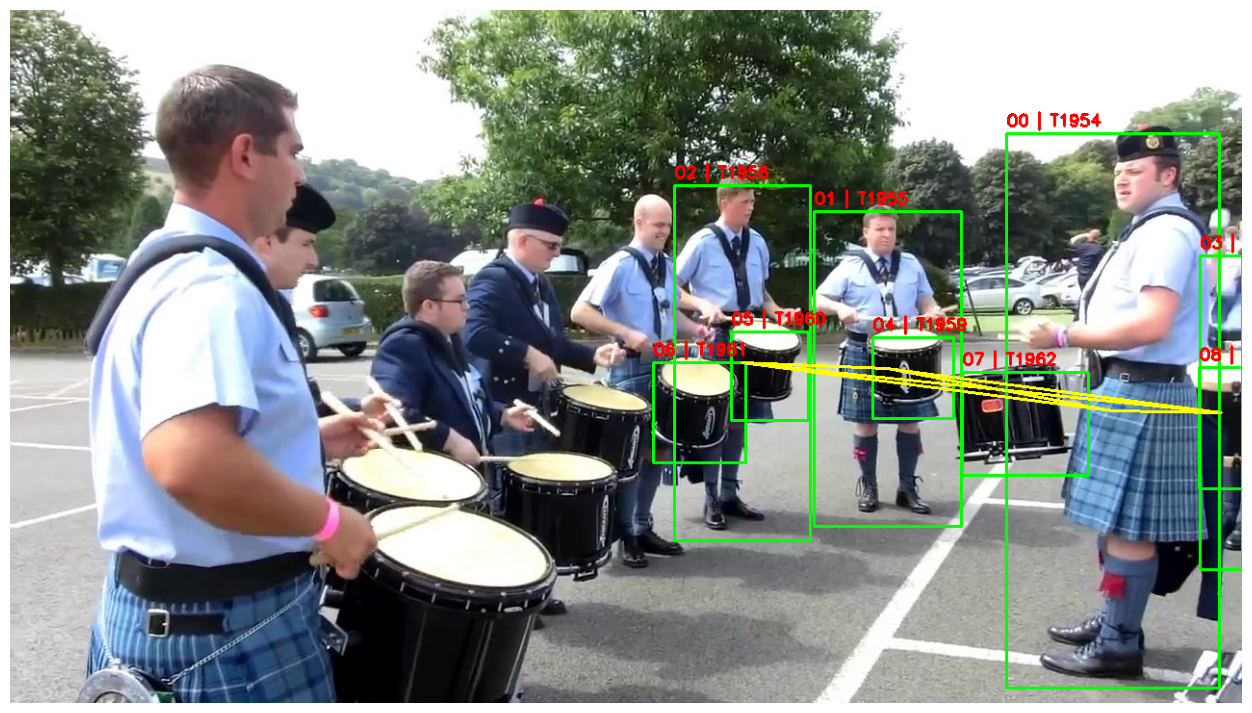

Object Index : 0
Track ID     : 1954
BBox         : [1035, 128, 221, 576]
Panoptic Cat : 405
Instance Cat : 805
Appearance:
   • blue and is
Situation:
   • prisoner of the Gestapo
--------------------------------------------------------------------------------
Object Index : 1
Track ID     : 1955
BBox         : [835, 209, 153, 327]
Panoptic Cat : 405
Instance Cat : 805
Appearance:
   • hat and is
Situation:
   • prisoner of the Gestapo
--------------------------------------------------------------------------------
Object Index : 2
Track ID     : 1956
BBox         : [690, 182, 141, 369]
Panoptic Cat : 405
Instance Cat : 805
Appearance:
   • hat and is
Situation:
   • standing there
--------------------------------------------------------------------------------
Object Index : 3
Track ID     : 1957
BBox         : [1236, 255, 44, 326]
Panoptic Cat : 405
Instance Cat : 805
Appearance:
   • hat and is
Situation:
   • standing there
---------------------------------------------------------

In [118]:
frame = target_data[10]

objects, edges = draw_frame(
    frame,
    dataset,
    frames_dir
)

print_objects(objects)
print_edges(edges)

In [101]:
def inspect_frame(frame):
    print("=" * 80)
    print("File:", frame["file_name"])
    print(f"Image size: {frame['width']} x {frame['height']}")
    print()

    print(f"Objects      : {len(frame['segments_info'])}")
    print(f"Annotations  : {len(frame['annotations'])}")
    print(f"Appearances  : {len(frame['appearances'])}")
    print(f"Situations   : {len(frame['situations'])}")
    print(f"Positions    : {len(frame['positions'])}")
    print(f"Interactions : {len(frame['interactions'])}")
    print(f"Relations    : {len(frame['relations'])}")

    print("\nObject mapping:")
    print("Idx | Track ID | BBox")
    print("-" * 50)

    for idx, (seg, ann) in enumerate(zip(frame["segments_info"], frame["annotations"])):
        print(f"{idx:3d} | {seg['track_id']:7d} | {ann['bbox']}")

In [102]:
inspect_frame(target_data[0])

File: train/HACS/Drum_corps_v_4KBTeNdE66U_scene_0_0-4062/frame0001.jpg
Image size: 1280 x 720

Objects      : 10
Annotations  : 10
Appearances  : 10
Situations   : 10
Positions    : 10
Interactions : 0
Relations    : 0

Object mapping:
Idx | Track ID | BBox
--------------------------------------------------
  0 |    1954 | [543, 23, 327, 697]
  1 |    1955 | [182, 135, 267, 585]
  2 |    1956 | [0, 68, 158, 652]
  3 |    1957 | [863, 151, 211, 569]
  4 |    1958 | [1173, 289, 107, 431]
  5 |    1959 | [294, 381, 151, 165]
  6 |    1960 | [0, 378, 158, 185]
  7 |    1961 | [0, 467, 39, 178]
  8 |    1962 | [426, 456, 221, 199]
  9 |    1963 | [847, 427, 172, 214]


In [119]:
print("405 =", dataset["thing_classes"][405])
print("805 =", dataset["thing_classes"][805])

405 = duct_tape
805 = phonebook


In [120]:
ids = sorted({s["category_id"] for s in frame["segments_info"]})
print(ids)

[405]


In [121]:
ids = sorted({a["category_id"] for a in frame["annotations"]})
print(ids)

[405, 805]


In [123]:
video_lookup = {v["id"]: v for v in dataset["videos"]}

video = video_lookup[frame["video_id"]]
pprint(video)

{'height': 720,
 'id': 302,
 'metadata': {'action': 'Drum_corps',
              'channel_id': 'UC7cGiJBQqtOumAOpB16yqEA',
              'channel_url': 'http://www.youtube.com/channel/UC7cGiJBQqtOumAOpB16yqEA',
              'dataset': 'HACS',
              'original_dataset_split': 'train',
              'scene': 'scene_0_0-4062',
              'uploader_id': 'AndrewYUpiper',
              'uploader_name': 'AndrewYUpiper',
              'youtube_id': '4KBTeNdE66U'},
 'name': 'train/HACS/Drum_corps_v_4KBTeNdE66U_scene_0_0-4062',
 'neg_category_ids': [112, 692, 1180, 16, 85, 127, 261],
 'not_exhaustive_category_ids': [805, 405],
 'width': 1280}


In [124]:
print(dataset.keys())

dict_keys(['data', 'videos', 'thing_classes', 'stuff_classes', 'predicate_apparances', 'predicate_situations', 'predicate_positions', 'predicate_interactions', 'predicate_relations'])


In [125]:
cat_ids = set()

for frame in dataset["data"]:
    for seg in frame["segments_info"]:
        cat_ids.add(seg["category_id"])

print(len(cat_ids))
print(sorted(cat_ids)[:50])

184
[4, 16, 20, 31, 32, 34, 35, 36, 38, 41, 60, 74, 79, 80, 81, 91, 95, 99, 110, 118, 126, 133, 136, 139, 152, 156, 160, 162, 174, 176, 180, 190, 191, 194, 197, 202, 208, 211, 221, 224, 229, 235, 237, 247, 262, 267, 289, 302, 303, 314]


In [127]:
from collections import Counter

counter = Counter()

for frame in dataset["data"]:
    for seg in frame["segments_info"]:
        counter[seg["category_id"]] += 1

counter.most_common(20)

[(805, 24734),
 (211, 4541),
 (41, 1212),
 (235, 814),
 (382, 797),
 (347, 781),
 (817, 670),
 (237, 659),
 (453, 599),
 (126, 557),
 (1144, 553),
 (95, 480),
 (133, 460),
 (851, 427),
 (660, 419),
 (110, 390),
 (35, 386),
 (980, 380),
 (139, 375),
 (180, 360)]

In [126]:
print(max(cat_ids))

1229


In [ ]:
# Create output directory if it doesn't exist
# os.makedirs(output_dir, exist_ok=True)

In [ ]:
# img_path = os.path.join(frames_dir, target_data[0]['file_name'])
# img_path

'c:\\Users\\Samuel Oliveira\\Desktop\\CS\\master-degree-project\\data\\TAO_Amodal_Dataset\\frames\\train/HACS/Drum_corps_v_4KBTeNdE66U_scene_0_0-4062/frame0001.jpg'